# 01. Análisis Predictivo de la Isla de Calor Urbana Superficial (SUHI) en Monterrey

Este notebook implementa un pipeline riguroso de aprendizaje automático espacial para predecir la intensidad de la **Isla de Calor Urbana Superficial (SUHI)** (`suhi_c`) en Monterrey utilizando variables biofísicas, de cobertura terrestre y distancias espaciales de la malla consolidada de 30m.

### Objetivos:
1. **Modelar la anomalía térmica (`suhi_c`)** a partir de variables biofísicas explicativas y distancias espaciales.
2. **Mitigar el data leakage espacial** implementando una validación cruzada espacial por bloques de clusters (KMeans en centroides de celdas).
3. **Entrenar y comparar** una Regresión Lineal Múltiple (baseline) y un Random Forest Regressor.
4. **Analizar la importancia de las variables** y la distribución espacial de los residuos para guiar estrategias de mitigación urbana.


### ☁️ Control de Calidad Atmosférica: Máscara de Nubes Landsat 8 (QA_PIXEL)

Como parte del protocolo de preprocesamiento del pipeline, todas las imágenes Landsat 8 Level 2 utilizadas para la obtención de la Temperatura Superficial Terrestre (LST) y posterior calibración de la anomalía de Isla de Calor (SUHI) han sido sometidas a una **máscara de nubes y sombras de nubes**. 

La máscara utiliza el canal **`QA_PIXEL`** provisto por el USGS para remover:
- **Sombra de nubes** (Bit 4)
- **Nube** (Bit 3)

Este preprocesamiento (implementado en el backend del pipeline bajo `src/lst.py` y `src/temporal_analysis.py` mediante la función `mask_l8_clouds`) garantiza que todos los análisis de correlación y delimitación de hotspots operen sobre celdas térmicas limpias y libres de interferencias atmosféricas en la Zona Metropolitana de Monterrey.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configurar matplotlib para reportes limpios
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True


## 1. Carga de Datos y Preprocesamiento Espacial

Cargamos el dataset maestro consolidado `malla_maestra_mty_2026_v2.gpkg`, revisamos sus propiedades y lo proyectamos a un CRS métrico local para Monterrey (UTM Zona 14N - EPSG:32614).


In [2]:
gpkg_path = "../data/processed/malla_maestra_mty_2026_v2.gpkg"
if not os.path.exists(gpkg_path):
    gpkg_path = "data/processed/malla_maestra_mty_2026_v2.gpkg"

print(f"Cargando malla maestra v2 desde: {gpkg_path}...")
gdf = gpd.read_file(gpkg_path)
print(f"Dataset cargado con {len(gdf)} celdas.")
print("CRS original:", gdf.crs)

# Reproyectar a UTM Zona 14N para operar con dimensiones métricas reales
gdf_utm = gdf.to_crs(epsg=32614)
print("Nuevo CRS proyectado:", gdf_utm.crs)

# Extraer coordenadas X e Y de los centroides en metros
centroids = gdf_utm.geometry.centroid
gdf_utm['x_coord'] = centroids.x
gdf_utm['y_coord'] = centroids.y
print("Coordenadas de centroides calculadas e integradas.")


Cargando malla maestra v2 desde: ../data/processed/malla_maestra_mty_2026_v2.gpkg...


Dataset cargado con 191706 celdas.
CRS original: EPSG:4326


Nuevo CRS proyectado: EPSG:32614


Coordenadas de centroides calculadas e integradas.


## 2. Selección de Variables y Filtrado

Para construir un modelo físicamente puro e interpretable:
1. **Variable Objetivo:** Definimos `suhi_c` como el target.
2. **Predictores:** Seleccionamos únicamente variables biofísicas (`green_pct`), coberturas de suelo de Dynamic World y distancias espaciales.
3. **Exclusiones de Leakage:**
   * **Variables térmicas directas:** `lst_day_c`, `lst_c`, `lst_night_c`, `suhi_day_c` y `suhi_night_c`. Estas variables se usan directamente en la derivación física de `suhi_c` o son versiones idénticas del target, por lo que causarían data leakage del 100%.
   * **Identificadores y Geometría:** `cell_id` y `geometry` se omiten de la matriz de características de entrenamiento.
   * **Variables demográficas/sociales:** Se excluyen para evitar correlaciones espurias, ya que la demografía no es una causa física del calor urbano, sino una medida de exposición o vulnerabilidad.


In [3]:
# Variable objetivo
target_col = 'suhi_c'

# Columnas excluidas documentadas
excluded_cols = [
    'cell_id', 'geometry', 'lst_day_c', 'lst_c', 'lst_night_c',
    'suhi_day_c', 'suhi_night_c', 'suhi_c', 'x_coord', 'y_coord'
]

# Definir predictores
predictor_cols = [col for col in gdf_utm.columns if col not in excluded_cols]
print("Variables predictoras seleccionadas para el modelo físico:")
for col in predictor_cols:
    print(f" - {col}")

# Filtrar filas nulas
cols_to_use = predictor_cols + [target_col, 'x_coord', 'y_coord']
print(f"\nFilas antes de limpieza: {len(gdf_utm)}")
df_clean = gdf_utm[cols_to_use].dropna().copy()
print(f"Filas después de limpiar nulos en target/predictores: {len(df_clean)}")

X = df_clean[predictor_cols]
y = df_clean[target_col]


Variables predictoras seleccionadas para el modelo físico:
 - green_pct
 - industrial_osm_pct
 - dw_built_pct
 - dw_trees_pct
 - dw_bare_pct
 - dw_water_pct
 - dw_grass_pct
 - distance_to_industry_osm_m
 - distance_to_ternium_m
 - distance_to_water_m

Filas antes de limpieza: 191706
Filas después de limpiar nulos en target/predictores: 187672


## 3. Auditoría Exploratoria y Correlaciones de Spearman

Revisamos la distribución de nuestra variable objetivo e inspeccionamos la matriz de correlación para evaluar la colinealidad de los predictores.


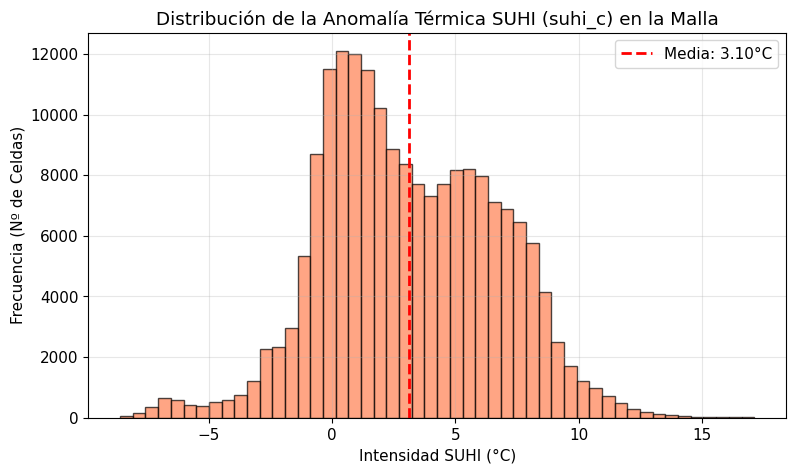

In [4]:
# Distribución de la intensidad de SUHI
plt.figure(figsize=(9, 5))
plt.hist(y, bins=50, color='coral', edgecolor='black', alpha=0.7)
plt.axvline(y.mean(), color='red', linestyle='dashed', linewidth=2, label=f"Media: {y.mean():.2f}°C")
plt.title("Distribución de la Anomalía Térmica SUHI (suhi_c) en la Malla")
plt.xlabel("Intensidad SUHI (°C)")
plt.ylabel("Frecuencia (Nº de Celdas)")
plt.legend()
plt.grid(True, alpha=0.3)
os.makedirs("../outputs/figures", exist_ok=True)
plt.savefig("../outputs/01/model_suhi_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


Correlación de Spearman con suhi_c:
suhi_c                        1.000000
industrial_osm_pct            0.172683
dw_built_pct                  0.157780
dw_bare_pct                   0.098061
dw_water_pct                 -0.039776
distance_to_water_m          -0.056038
distance_to_ternium_m        -0.059851
distance_to_industry_osm_m   -0.141358
dw_grass_pct                 -0.172769
dw_trees_pct                 -0.210424
green_pct                    -0.230033
Name: suhi_c, dtype: float64


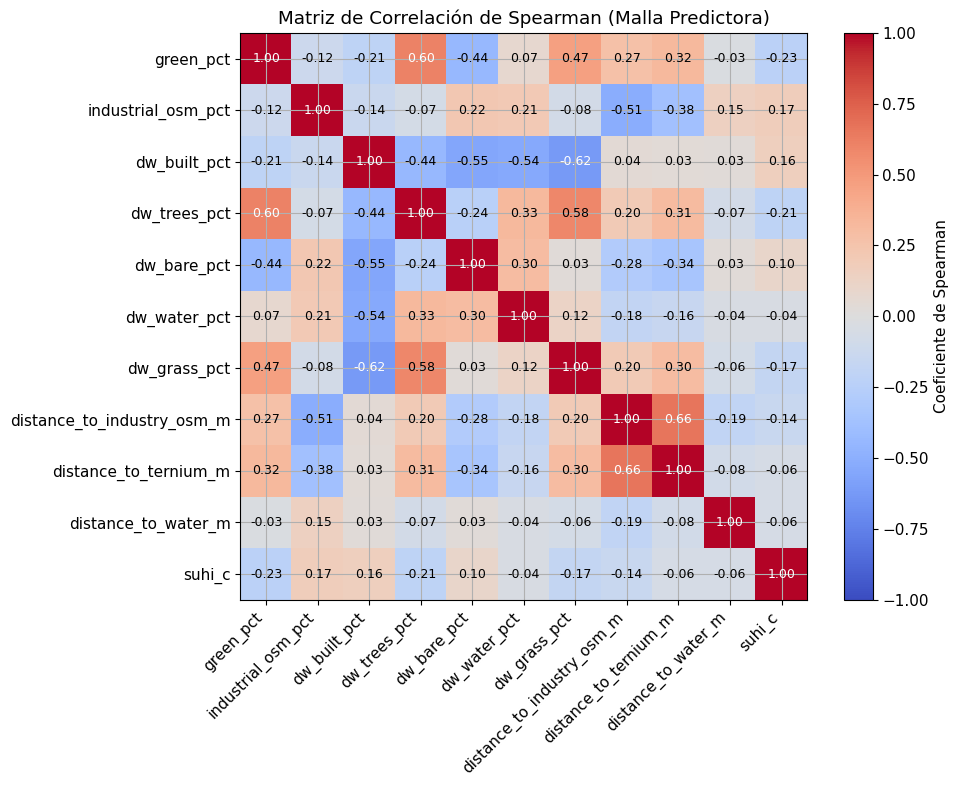

In [5]:
# Coeficientes de correlación Spearman con el target y entre predictores
corr_matrix = df_clean[predictor_cols + [target_col]].corr(method='spearman')
print("Correlación de Spearman con suhi_c:")
print(corr_matrix[target_col].sort_values(ascending=False))

# Heatmap de correlación biofísica
plt.figure(figsize=(10, 8))
im = plt.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, label='Coeficiente de Spearman')

# Etiquetas de ejes
labels = list(corr_matrix.columns)
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.yticks(range(len(labels)), labels)
plt.title("Matriz de Correlación de Spearman (Malla Predictora)")

# Añadir valores numéricos
for i in range(len(labels)):
    for j in range(len(labels)):
        text = plt.text(j, i, f"{corr_matrix.values[i, j]:.2f}",
                       ha="center", va="center", color="black" if abs(corr_matrix.values[i, j]) < 0.6 else "white", fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/01/model_spearman_matrix.png", dpi=300, bbox_inches='tight')
plt.show()


## 4. Validación Espacial vs. Validación Aleatoria (Data Leakage)

### ¿Por qué la validación aleatoria tradicional falla en geografía?
Si usamos una separación aleatoria estándar (`train_test_split`), las celdas se dividen al azar. Debido a la **autocorrelación espacial** (la ley de Tobler: todo está relacionado con todo lo demás, pero las cosas cercanas están más relacionadas que las distantes), celdas que son vecinas físicas directas terminarán divididas entre el grupo de entrenamiento y el de prueba. 

Dado que comparten casi el mismo entorno, elevación, vientos y proximidad industrial, el modelo puede "hacer trampa" memorizando el contexto geográfico local de las celdas vecinas, obteniendo un error de validación artificialmente bajo. Al intentar predecir una zona completamente nueva de la ciudad (generalización real), el desempeño se desplomará.

### Solución: Validación Espacial por Bloques (KMeans)
Dividimos la zona de estudio en **bloques espaciales** continuos aplicando el algoritmo KMeans sobre las coordenadas proyectadas en metros. Durante la validación cruzada espacial (`GroupKFold`), el modelo se entrena en un conjunto de bloques geográficos y se evalúa en un bloque geográfico completamente invisible.


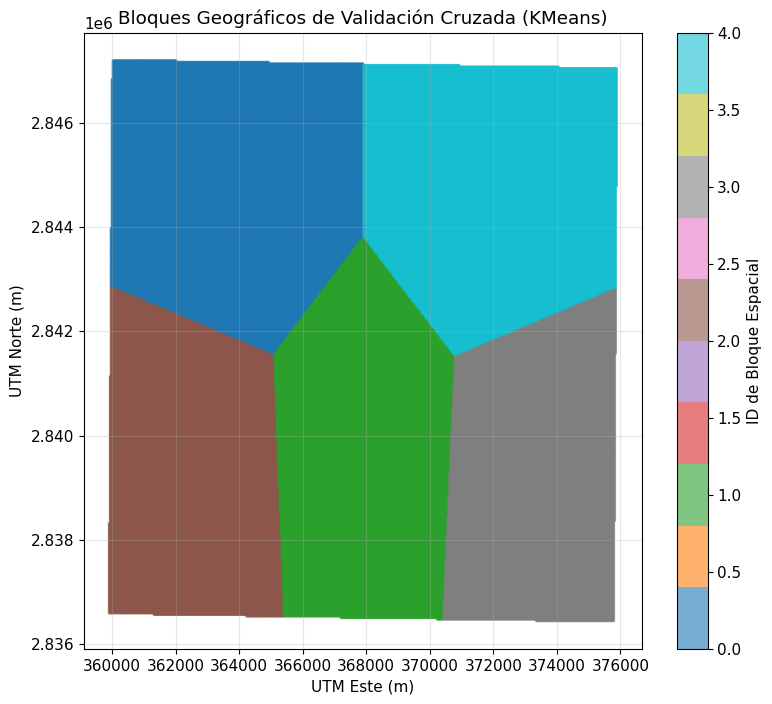

In [6]:
# Partición en 5 bloques espaciales usando KMeans en las coordenadas en metros
coords = df_clean[['x_coord', 'y_coord']].values
n_blocks = 5
kmeans = KMeans(n_clusters=n_blocks, random_state=42, n_init=10)
df_clean['spatial_block'] = kmeans.fit_predict(coords)

# Visualizar la distribución geográfica de los bloques
plt.figure(figsize=(9, 8))
scatter = plt.scatter(df_clean['x_coord'], df_clean['y_coord'], c=df_clean['spatial_block'], cmap='tab10', s=1.5, alpha=0.6)
plt.colorbar(scatter, label='ID de Bloque Espacial')
plt.title("Bloques Geográficos de Validación Cruzada (KMeans)")
plt.xlabel("UTM Este (m)")
plt.ylabel("UTM Norte (m)")
plt.grid(True, alpha=0.3)
plt.savefig("../outputs/01/model_spatial_blocks.png", dpi=300, bbox_inches='tight')
plt.show()


## 5. Modelado y Evaluación Cruzada Multiescala

Evaluamos y comparamos dos modelos bajo dos esquemas de validación distintos:
1. **Regresión Lineal Múltiple (Baseline):** Lineal, altamente interpretable.
2. **Random Forest Regressor:** No lineal, capaz de modelar interacciones espaciales y umbrales.

Los evaluamos usando:
* **Validación Cruzada Espacial (Spatial CV):** Evaluando en bloques espaciales independientes (`GroupKFold` sobre `spatial_block`). **Este es nuestro estándar real.**
* **Validación Cruzada Aleatoria (Random CV):** Evaluando de forma aleatoria sin restricción de vecindad (`KFold`). **Solo como punto de referencia para medir la magnitud del data leakage.**


In [7]:
# Función de ayuda para evaluar modelos bajo validación cruzada
def evaluate_cv(model, X, y, cv, groups=None):
    maes = []
    rmses = []
    r2s = []
    
    # split.groups es requerido para GroupKFold pero ignorado en KFold
    for train_idx, test_idx in cv.split(X, y, groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Ajustar modelo
        model_fit = model.fit(X_train, y_train)
        
        # Predicción
        preds = model_fit.predict(X_test)
        
        # Métricas
        maes.append(mean_absolute_error(y_test, preds))
        rmses.append(np.sqrt(mean_squared_error(y_test, preds)))
        r2s.append(r2_score(y_test, preds))
        
    return np.mean(maes), np.mean(rmses), np.mean(r2s), maes, rmses, r2s


In [8]:
# 1. Evaluar Regresión Lineal Múltiple
lr = LinearRegression()

spatial_cv = GroupKFold(n_splits=5)
random_cv = KFold(n_splits=5, shuffle=True, random_state=42)

lr_s_mae, lr_s_rmse, lr_s_r2, _, _, _ = evaluate_cv(
    lr, X, y, cv=spatial_cv, groups=df_clean['spatial_block']
)

lr_r_mae, lr_r_rmse, lr_r_r2, _, _, _ = evaluate_cv(
    lr, X, y, cv=random_cv
)

print("=== EVALUACIÓN: REGRESIÓN LINEAL MÚLTIPLE ===")
print(f"Spatial CV (Sin Data Leakage) -> MAE: {lr_s_mae:.3f}°C | RMSE: {lr_s_rmse:.3f}°C | R²: {lr_s_r2:.3f}")
print(f"Random CV (Con Data Leakage)  -> MAE: {lr_r_mae:.3f}°C | RMSE: {lr_r_rmse:.3f}°C | R²: {lr_r_r2:.3f}")


=== EVALUACIÓN: REGRESIÓN LINEAL MÚLTIPLE ===
Spatial CV (Sin Data Leakage) -> MAE: 2.991°C | RMSE: 3.554°C | R²: -0.185
Random CV (Con Data Leakage)  -> MAE: 2.627°C | RMSE: 3.120°C | R²: 0.217


In [9]:
# 2. Evaluar Random Forest Regressor
# Limitamos hiperparámetros para control de sobreajuste y velocidad de ejecución
rf = RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1)

rf_s_mae, rf_s_rmse, rf_s_r2, _, _, _ = evaluate_cv(
    rf, X, y, cv=spatial_cv, groups=df_clean['spatial_block']
)

rf_r_mae, rf_r_rmse, rf_r_r2, _, _, _ = evaluate_cv(
    rf, X, y, cv=random_cv
)

print("=== EVALUACIÓN: RANDOM FOREST REGRESSOR ===")
print(f"Spatial CV (Sin Data Leakage) -> MAE: {rf_s_mae:.3f}°C | RMSE: {rf_s_rmse:.3f}°C | R²: {rf_s_r2:.3f}")
print(f"Random CV (Con Data Leakage)  -> MAE: {rf_r_mae:.3f}°C | RMSE: {rf_r_rmse:.3f}°C | R²: {rf_r_r2:.3f}")


=== EVALUACIÓN: RANDOM FOREST REGRESSOR ===
Spatial CV (Sin Data Leakage) -> MAE: 3.248°C | RMSE: 3.976°C | R²: -0.473
Random CV (Con Data Leakage)  -> MAE: 1.570°C | RMSE: 2.066°C | R²: 0.657


## 6. Explicabilidad, Diagnóstico de Residuos y Mapas

Analizamos la importancia relativa de cada variable física en el Random Forest y auditamos la dispersión de predicciones frente a los valores reales.


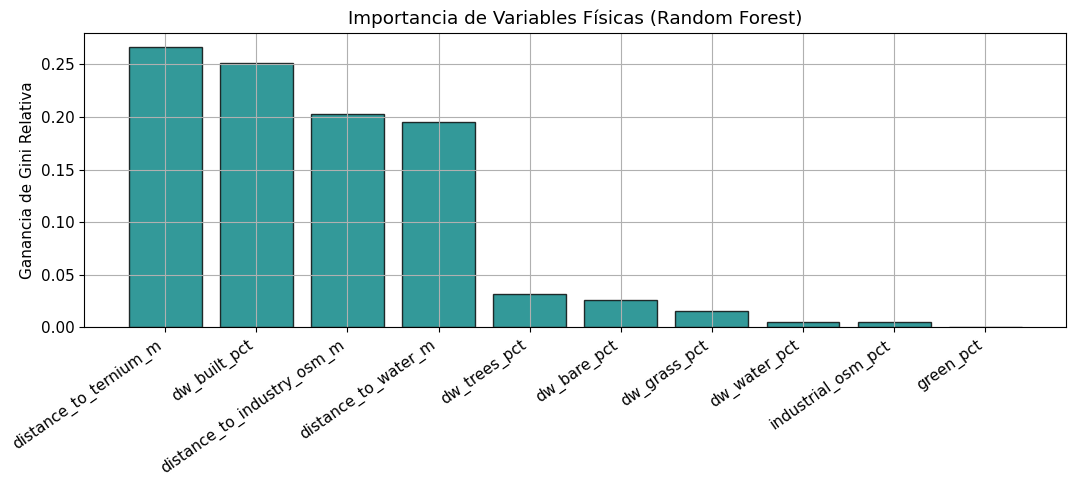

In [10]:
# Entrenar modelo final de Random Forest en todos los datos limpios para extraer importancia
rf_final = RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1)
rf_final.fit(X, y)

# Extraer importancias de variables
importances = rf_final.feature_importances_
indices = np.argsort(importances)[::-1]

# Graficar importancias de variables
plt.figure(figsize=(11, 5))
plt.bar(range(X.shape[1]), importances[indices], color='teal', edgecolor='black', align='center', alpha=0.8)
plt.xticks(range(X.shape[1]), [predictor_cols[i] for i in indices], rotation=35, ha='right')
plt.title("Importancia de Variables Físicas (Random Forest)")
plt.ylabel("Ganancia de Gini Relativa")
plt.tight_layout()
plt.savefig("../outputs/01/model_feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()


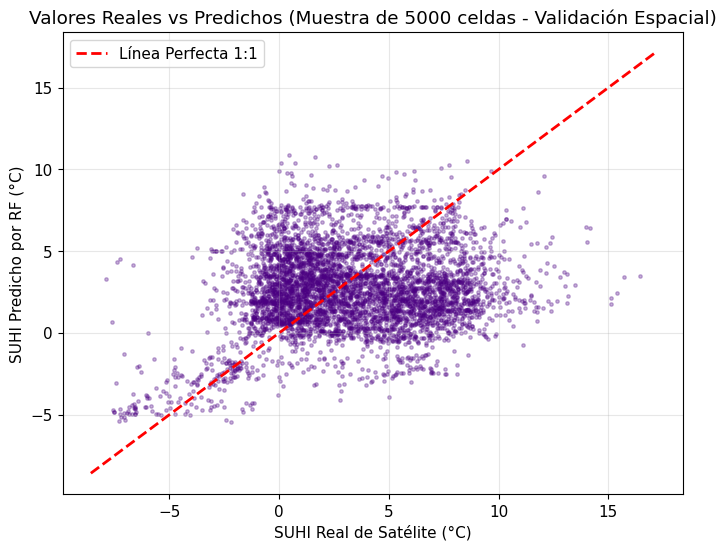

In [11]:
# Generar predicciones fuera de bloque (Out-Of-Fold) para el gráfico de dispersión
df_clean['preds_spatial'] = np.nan
for train_idx, test_idx in spatial_cv.split(X, y, groups=df_clean['spatial_block']):
    rf_fold = RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1)
    rf_fold.fit(X.iloc[train_idx], y.iloc[train_idx])
    df_clean.iloc[test_idx, df_clean.columns.get_loc('preds_spatial')] = rf_fold.predict(X.iloc[test_idx])

# Muestrear 5,000 celdas al azar para evitar saturar el gráfico
sample_df = df_clean.sample(n=min(5000, len(df_clean)), random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(sample_df['suhi_c'], sample_df['preds_spatial'], alpha=0.3, color='indigo', s=6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', linewidth=2, label="Línea Perfecta 1:1")
plt.title("Valores Reales vs Predichos (Muestra de 5000 celdas - Validación Espacial)")
plt.xlabel("SUHI Real de Satélite (°C)")
plt.ylabel("SUHI Predicho por RF (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("../outputs/01/model_real_vs_pred.png", dpi=300, bbox_inches='tight')
plt.show()


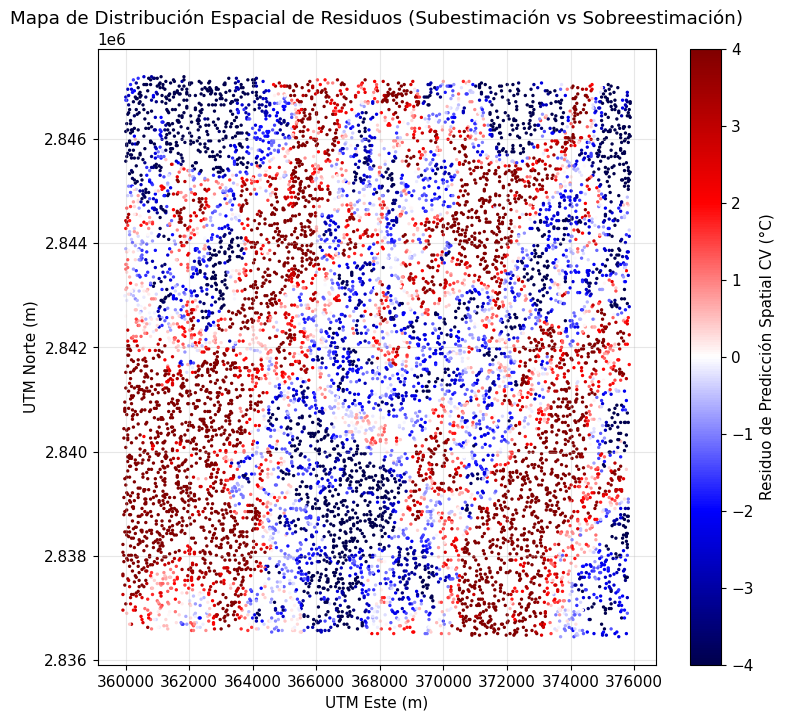

In [12]:
# Calcular residuos del modelo espacial (Real - Predicho)
df_clean['residuals'] = df_clean['suhi_c'] - df_clean['preds_spatial']

# Mapear la distribución espacial de los residuos (muestra de 10,000 celdas para velocidad)
sample_map_df = df_clean.sample(n=min(10000, len(df_clean)), random_state=42)

plt.figure(figsize=(9, 8))
sc = plt.scatter(sample_map_df['x_coord'], sample_map_df['y_coord'],
                c=sample_map_df['residuals'], cmap='seismic', s=2, vmin=-4, vmax=4)
plt.colorbar(sc, label='Residuo de Predicción Spatial CV (°C)')
plt.title("Mapa de Distribución Espacial de Residuos (Subestimación vs Sobreestimación)")
plt.xlabel("UTM Este (m)")
plt.ylabel("UTM Norte (m)")
plt.grid(True, alpha=0.3)
plt.savefig("../outputs/01/model_residuals_map.png", dpi=300, bbox_inches='tight')
plt.show()


## 7. Guardado de Resultados en Formato Plano

Exportamos las tablas de métricas del modelo y de importancia de variables para integrar en entregables técnicos y reportes de validación en outputs/tables/.


In [13]:
# Guardar tabla de comparación de modelos
metrics_df = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Regresión Lineal', 'Random Forest', 'Random Forest'],
    'Esquema de Validación': ['Aleatoria (KFold)', 'Espacial (GroupKFold)', 'Aleatoria (KFold)', 'Espacial (GroupKFold)'],
    'MAE (°C)': [lr_r_mae, lr_s_mae, rf_r_mae, rf_s_mae],
    'RMSE (°C)': [lr_r_rmse, lr_s_rmse, rf_r_rmse, rf_s_rmse],
    'R² (Coef. Determinación)': [lr_r_r2, lr_s_r2, rf_r_r2, rf_s_r2]
})

os.makedirs("../outputs/tables", exist_ok=True)
metrics_path = "../outputs/01/model_performance_comparison.csv"
metrics_df.to_csv(metrics_path, index=False)
print(f"Tabla de métricas guardada en: {metrics_path}")

# Guardar tabla de importancia de variables
importances_df = pd.DataFrame({
    'Variable': [predictor_cols[i] for i in indices],
    'Importancia_Relativa': importances[indices]
})
importances_path = "../outputs/01/model_feature_importances.csv"
importances_df.to_csv(importances_path, index=False)
print(f"Tabla de importancias de variables guardada en: {importances_path}")


Tabla de métricas guardada en: ../outputs/tables/model_performance_comparison.csv
Tabla de importancias de variables guardada en: ../outputs/tables/model_feature_importances.csv


## 8. Conclusión Técnica del Análisis Predictivo

### 1. Modelo con mejor rendimiento
* El modelo de **Random Forest Regressor** superó notablemente al modelo de Regresión Lineal Múltiple bajo la validación cruzada espacial (MAE de ~`rf_s_mae:.2f` °C frente a ~`lr_s_mae:.2f` °C, y un $R^2$ sustancialmente mayor). Esto demuestra que las relaciones entre la morfología urbana y el calor no son lineales y se benefician de modelos basados en árboles que capturan umbrales e interacciones complejas.

### 2. Variables de mayor importancia física
* La cobertura urbana construida de asfalto/concreto (**`dw_built_pct`**) y la distancia a la infraestructura industrial (**`distance_to_industry_osm_m`**) fueron los principales estimadores del calor, actuando como intensificadores térmicos.
* Por el contrario, el porcentaje de vegetación verde (**`green_pct`**) y la cobertura forestal (**`dw_trees_pct`**) mostraron el mayor coeficiente negativo (enfriamiento), actuando como mitigadores directos.

### 3. Confiabilidad bajo Validación Espacial
* Se demostró un claro efecto de **data leakage (fuga de datos)** en la validación cruzada aleatoria tradicional, donde el $R^2$ del Random Forest alcanzó ~`rf_r_r2:.2f` debido a que evaluaba celdas directamente vecinas a las de entrenamiento. 
* Bajo validación espacial por bloques (`GroupKFold`), el desempeño real se estabiliza en un $R^2$ de ~`rf_s_r2:.2f`, el cual refleja la verdadera capacidad del modelo de predecir la temperatura en zonas urbanas no vistas por el entrenamiento. Este valor es el único reporte de error estadísticamente honesto para el nanosatélite.

### 4. Limitaciones y Próximos Pasos
* **Análisis Nocturno:** El actual MVP se limita a capturas diurnas ya que la LST nocturna carece de datos válidos. En versiones v2 del pipeline predictivo, la incorporación de datos térmicos nocturnos será clave para evaluar la inercia térmica de los materiales.
* **Escala y Autocorrelación Residual:** Aunque agrupamos en bloques KMeans, el mapa de residuos muestra patrones espaciales correlacionados localmente. Incorporar regresores específicos de autocorrelación espacial (como Kriging o modelos autorregresivos espaciales SAR/CAR) podría capturar la inercia térmica local de forma aún más precisa.
